In [1]:
import pyBigWig
bw = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold0_chr6_w_bias.bw")

# Fetch values from chr6: full chromosome
chrom = "chr6"
length = bw.chroms()[chrom]  # get chr6 length from file

# Fetch values as a NumPy array
signal_chr6 = bw.values(chrom, 0, length)  # start=0, end=chrom_length

# Close the file
bw.close()

In [2]:
printbw = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/printTn5bias.bw")

# Fetch values from chr6: full chromosome
chrom = "chr6"
length = printbw.chroms()[chrom]  # get chr6 length from file

# Fetch values as a NumPy array
print_chr6 = printbw.values(chrom, 0, length)  # start=0, end=chrom_length

# Close the file
printbw.close()

In [3]:
import numpy as np
signal_chr6=np.nan_to_num(signal_chr6)
print_chr6=np.nan_to_num(print_chr6)


In [4]:
import pandas as pd
data=pd.read_csv("/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/ATAC_PE/GM12878/nautilus_runs/GM12878_03.01.2022_bias_128_4_1234_0.4_fold_0/train_test_regions_bias/nonpeaks.testset.bed.gz", sep='\t', header=None)


In [5]:
#data[data[0]=="chr6"].shape

In [6]:
from scipy.stats import pearsonr
observed = pyBigWig.open("/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/ATAC_PE/GM12878/data/GM12878_unstranded.bw")
printbw = pyBigWig.open("printTn5bias.bw")



RuntimeError: Received an error during file opening!

In [ ]:
pearsonrs_print=[]
pearsonrs_chrombpnet=[]
distribution=[]
signal=[]
for chrom in ["chr1", "chr6", "chr3"]:
    bw = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold0_"+chrom+"_w_bias.bw")
    newd = data[data[0]==chrom]
    for i,r in newd.iterrows():
        start=r[1]+r[9]-500
        end=r[1]+r[9]+500
        obs = np.nan_to_num(observed.values(chrom, start, end))
        signal1 = np.nan_to_num(printbw.values(chrom, start, end))
        distribution.append(sum(signal1))
        signal.append(signal1)
        signal2 = np.nan_to_num(bw.values(chrom, start, end))
        #print(sum(signal2))
        pearsonrs_print.append(pearsonr(obs, signal1))
        pearsonrs_chrombpnet.append(pearsonr(obs, signal2))
        #break

In [ ]:
#pearsonrs_print

In [ ]:
#pearsonrs_chrombpnet

In [ ]:
# import matplotlib.pyplot as plt
# plt.hist(pearsonrs_print, label="print")
# plt.hist(pearsonrs_chrombpnet, label="chrombpnet")

In [ ]:
#plt.scatter(pearsonrs_chrombpnet, pearsonrs_print)
import matplotlib.pyplot as plt

Text(0, 0.5, 'PRINT')

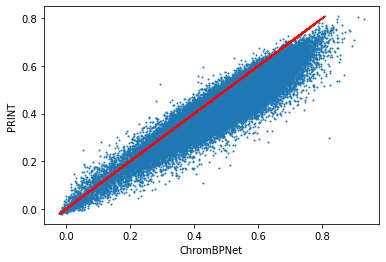

In [14]:
pearsonrs_print = [x[0] for x in pearsonrs_print]
pearsonrs_chrombpnet = [x[0] for x in pearsonrs_chrombpnet]

plt.plot(pearsonrs_print, pearsonrs_print, c='r')
plt.scatter(pearsonrs_chrombpnet, pearsonrs_print, s=1)
plt.xlabel("ChromBPNet")
plt.ylabel("PRINT")

In [15]:
#chrom
chrom="chr3"
start=165351000+1057-500
end=165351000+1057+500
#chr3	127212000	127214114

obs = np.nan_to_num(observed.values(chrom, start, end))
signal1 = np.nan_to_num(printbw.values(chrom, start, end))
signal2 = np.nan_to_num(bw.values(chrom, start, end))

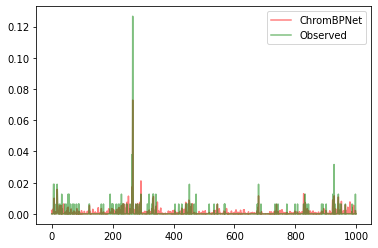

In [16]:
#plt.plot(signal1/sum(signal1), label="PRINT", c='b', alpha=0.5)
plt.plot(signal2/sum(signal2), label="ChromBPNet", c='r', alpha=0.5)
plt.plot(obs/sum(obs), label="Observed", c='g', alpha=0.5)
plt.legend()

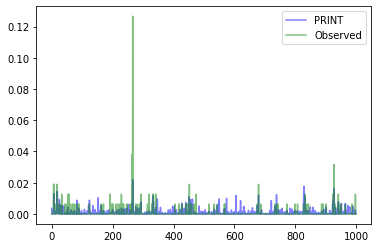

In [17]:
plt.plot(signal1/sum(signal1), label="PRINT", c='b', alpha=0.5)
#plt.plot(signal2/sum(signal2), label="ChromBPNet", c='r', alpha=0.5)
plt.plot(obs/sum(obs), label="Observed", c='g', alpha=0.5)
plt.legend()

In [18]:
pearsonrs_print[-1]

0.4768210948445395

In [19]:
newd.shape

(19177, 10)

In [20]:
newd["chrombpnet"] = pearsonrs_chrombpnet[-newd.shape[0]:]
newd["print"] = pearsonrs_print[-newd.shape[0]:]

/users/anusri/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/users/anusri/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [21]:
newd[(newd["print"]<0.6) & (newd["chrombpnet"]>0.8)]

,0,1,2,3,4,5,6,7,8,9,chrombpnet,print
17450,chr3,127212000,127214114,.,.,.,.,.,.,1057,0.822564,0.580915
26214,chr3,165351000,165353114,.,.,.,.,.,.,1057,0.852312,0.536697
40634,chr3,13338000,13340114,.,.,.,.,.,.,1057,0.821751,0.599946
41941,chr3,39727000,39729114,.,.,.,.,.,.,1057,0.804421,0.515041


In [24]:
from scipy.stats import pearsonr
observed = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/data/naked_unstranded.bw")
printbw = pyBigWig.open("printTn5bias.bw")


pearsonrs_print=[]
pearsonrs_chrombpnet=[]
datar = []
for chrom in ["chr1"]:
    bw = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold0_"+chrom+"_w_bias.bw")
    newd = data[data[0]==chrom]
    for i,r in newd.iterrows():
        start=r[1]+r[9]-1000
        end=r[1]+r[9]+1000
        obs = np.nan_to_num(observed.values(chrom, start, end))
        if sum(obs) < 50:
            continue
        datar.append((start, end))
        signal1 = np.nan_to_num(printbw.values(chrom, start, end))
        signal2 = np.nan_to_num(bw.values(chrom, start, end))
        #print(sum(signal2))
        pearsonrs_print.append(pearsonr(obs, signal1))
        pearsonrs_chrombpnet.append(pearsonr(obs, signal2))
        #break

In [26]:
#obs
#datar

[(168970057, 168972057),
 (2180057, 2182057),
 (10467057, 10469057),
 (2162057, 2164057),
 (201996057, 201998057),
 (2238057, 2240057),
 (2148057, 2150057),
 (2136057, 2138057),
 (202064057, 202066057),
 (2224057, 2226057),
 (2207057, 2209057),
 (47215057, 47217057),
 (2150057, 2152057),
 (10370057, 10372057),
 (69362057, 69364057),
 (2270057, 2272057),
 (2272057, 2274057),
 (46928057, 46930057),
 (47225057, 47227057),
 (202101057, 202103057),
 (173272057, 173274057),
 (149437057, 149439057),
 (201991057, 201993057),
 (2124057, 2126057),
 (2237057, 2239057),
 (149540057, 149542057),
 (10437057, 10439057),
 (222389057, 222391057),
 (202045057, 202047057),
 (2142057, 2144057),
 (46930057, 46932057),
 (34552057, 34554057),
 (222342057, 222344057),
 (168986057, 168988057),
 (168910057, 168912057),
 (2209057, 2211057),
 (173238057, 173240057),
 (149463057, 149465057),
 (168914057, 168916057),
 (2166057, 2168057),
 (46936057, 46938057),
 (47206057, 47208057),
 (222245057, 222247057),
 (46929

In [27]:
#pearsonrs_print

[(0.7219866305271168, 6.4e-322),
 (0.9314270671897346, 0.0),
 (0.9324835138860119, 0.0),
 (0.9196530440261881, 0.0),
 (0.8907645929147778, 0.0),
 (0.908968196384375, 0.0),
 (0.8903994522123369, 0.0),
 (0.946904206985034, 0.0),
 (0.9269340735023912, 0.0),
 (0.9059498982711439, 0.0),
 (0.9162525663703847, 0.0),
 (0.9039920687752461, 0.0),
 (0.9156029922374843, 0.0),
 (0.8870191395749656, 0.0),
 (0.8921634334637849, 0.0),
 (0.9505270521811517, 0.0),
 (0.924149451022191, 0.0),
 (0.26040031743750425, 2.3373598514130308e-32),
 (0.9072245555222835, 0.0),
 (0.8898285009303403, 0.0),
 (0.9088421260217799, 0.0),
 (0.512318811190094, 2.838039854620293e-134),
 (0.9344029129601765, 0.0),
 (0.831022259548847, 0.0),
 (0.9290411630813429, 0.0),
 (0.06754959966346656, 0.002507176906534047),
 (0.9228267018658202, 0.0),
 (0.9267799431262848, 0.0),
 (0.9174269351201172, 0.0),
 (0.8643974572331411, 0.0),
 (0.13398299721651438, 1.7955891869419988e-09),
 (0.9118025582735181, 0.0),
 (0.920051368914076, 0.0),


In [ ]:
pearsonrs_print = [x[0] for x in pearsonrs_print]
pearsonrs_chrombpnet = [x[0] for x in pearsonrs_chrombpnet]

plt.plot(pearsonrs_print, pearsonrs_print, c='r')
plt.scatter(pearsonrs_chrombpnet, pearsonrs_print, s=1)
# plt.xlim(0.7,1)
# plt.ylim(0.7,1)
plt.xlabel("ChromBPNet")
plt.ylabel("PRINT")

In [182]:
len(pearsonrs_chrombpnet)

327

In [183]:
np.median(pearsonrs_chrombpnet)

0.9066187172845798

In [184]:
np.median(pearsonrs_print)

0.90887100319195

In [112]:
#pearsonrs_chrombpnet
pearsonrs_print

[0.7533663738792107,
 0.9302785925969268,
 0.9440427454190662,
 0.9187189692898708,
 0.9379094891149385,
 0.8941536203651885,
 0.9075576801276679,
 0.9476303238660273,
 0.9389417973163398,
 0.923727813692497,
 0.8907506241309026,
 -0.008016418359915638,
 0.9058032792296171,
 0.912471412453102,
 0.8178189788156014,
 0.9273552487729351,
 0.9498920618609322,
 0.9237732887594408,
 0.22197156098956766,
 0.9122469897461514,
 0.8601263095805323,
 0.9254665442017407,
 0.4957582756968123,
 0.9250817128917576,
 0.9165913895378,
 0.9259131222720225,
 0.9393550563917881,
 0.9362821969895914,
 0.923558694391668,
 0.9349913454776038,
 0.24115668832791096,
 0.9219927328010037,
 0.9175585691495627,
 0.08565346454935097,
 0.7784493754467225,
 0.8297077089685434,
 0.9428108467049625,
 0.9346131410081447,
 0.5616860560649293,
 0.674612162849103,
 0.9146592282926972,
 0.054313415202745,
 0.8403079012275351,
 0.9308564882632865,
 0.3372691177884975,
 0.9026050344147799,
 0.934558897939848,
 0.1468795736556

In [107]:
pearsonrs_chrombpnet

[0.7762151835436141,
 0.9328701901001131,
 0.937358145282983,
 0.9279872690812027,
 0.8988338955587054,
 0.9323645832905739,
 0.9150488171781997,
 0.9132944899017208,
 0.8866814778639122,
 0.8935117218692136,
 0.8876115415700702,
 -0.004574178502331509,
 0.8914255300901747,
 0.9218975509889091,
 0.9108486672522127,
 0.9148762525999641,
 0.8259187038614789,
 0.9138515003305623,
 0.21282831118285606,
 0.9204241688268118,
 0.9014520848858544,
 0.9184333383051332,
 0.44449578532296685,
 0.9330107673742583,
 0.7454736251364438,
 0.9360360709840424,
 0.8686498500684229,
 0.9431729656589849,
 0.9137244095569395,
 0.9058342069413512,
 0.15995375493927566,
 0.9450175052634437,
 0.9208469263065462,
 0.08845916472683847,
 0.7580665119830682,
 0.8327180431673491,
 0.9344529021101992,
 0.9571985692697115,
 0.620476346354255,
 0.7140488323849767,
 0.9122464799447279,
 0.06541522966296133,
 0.8991392537356223,
 0.8760893871515606,
 0.3506369247069496,
 0.8792197278031674,
 0.9536071804593911,
 0.2093

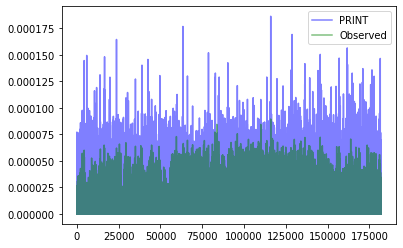

In [156]:
#chr1 9963058 11295918

#chrom
chrom="chr1"
 
#start=2115312
#end=2276873
#69256017 69397675
#start=69256017
#end=69397675
# start=80688374
# end=80857832
start=47116557
end=47298581
#chr3	127212000	127214114

obs = np.nan_to_num(observed.values(chrom, start, end))
signal1 = np.nan_to_num(printbw.values(chrom, start, end))
signal2 = np.nan_to_num(bw.values(chrom, start, end))

plt.plot(signal1/sum(signal1), label="PRINT", c='b', alpha=0.5)
#plt.plot(signal2/sum(signal2), label="ChromBPNet", c='r', alpha=0.5)
plt.plot(obs/sum(obs), label="Observed", c='g', alpha=0.5)
plt.legend()

In [163]:
pearsonr(obs[2000:4000], signal1[2000:4000])


(0.9134557083877468, 0.0)

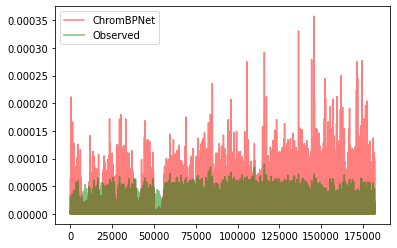

In [158]:

plt.plot(signal2/sum(signal2), label="ChromBPNet", c='r', alpha=0.5)
plt.plot(obs/sum(obs), label="Observed", c='g', alpha=0.5)
plt.legend()

In [162]:
#plt.plot(signal1/sum(signal1), label="PRINT", c='b', alpha=0.5)
pearsonr(obs, signal2)


(0.876704423754027, 0.0)

/users/anusri/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in true_divide
  


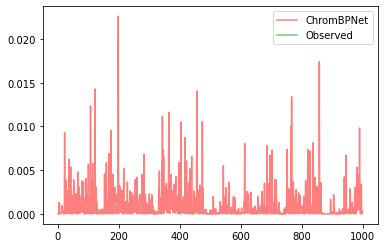

In [127]:
ps=signal2[1000:2000]/sum(signal2[1000:2000])
os=obs[1000:2000]/sum(obs[1000:2000])
plt.plot(ps, label="ChromBPNet", c='r', alpha=0.5)
plt.plot(os, label="Observed", c='g', alpha=0.5)
plt.legend()

In [117]:
pearsonr(obs, signal2)

(0.05552048613815321, 0.0)

In [135]:
index = np.arange(obs.shape[0])
index[obs>0]

array([    17110,     17808,     23893, ..., 101266592, 101270826,
       101270945])

(array([1.0000e+00, 7.0000e+00, 7.3000e+01, 3.7390e+03, 3.4326e+04,
        2.4306e+04, 4.4000e+02, 1.8000e+01, 8.0000e+00, 1.1000e+01]),
 array([ 467.91105725,  556.77833123,  645.6456052 ,  734.51287918,
         823.38015316,  912.24742714, 1001.11470112, 1089.9819751 ,
        1178.84924907, 1267.71652305, 1356.58379703]),
 <BarContainer object of 10 artists>)

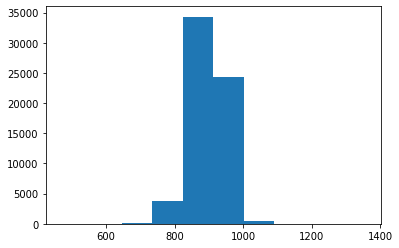

In [193]:
plt.hist(distribution)

In [196]:
signal = np.array(signal)

In [197]:
signal.shape

(62929, 1000)

In [200]:
row_sumrs = signal.sum(-1, keepdims=True)

In [204]:
signalv = signal / (row_sumrs + 1e-12)

In [206]:
signalv.shape

(62929, 1000)

In [208]:
sum(signalv[0])

0.9999999999999988

In [209]:
batch_logits = np.log(signalv + 1e-12)

/users/anusri/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log
  """Entry point for launching an IPython kernel.


In [213]:
np.isnan(batch_logits)

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [221]:
np.sum(np.isnan(batch_logits), axis=1)

array([0, 1, 0, ..., 2, 0, 0])

In [224]:
sum(np.isnan(signalv[1]))

0

In [226]:
np.arange(1000)[np.isnan(np.log(signalv[1] + 1e-12 ))]

/users/anusri/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log
  """Entry point for launching an IPython kernel.


array([841])

In [229]:
np.min(signal)

-0.006385046988725662

In [231]:
np.log(signalv[1] + 1e-12 )

/users/anusri/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log
  """Entry point for launching an IPython kernel.


array([ -7.36605191,  -8.5030276 ,  -9.98231061,  -9.09681035,
        -9.20494142,  -6.82605347, -10.14779038,  -9.89645737,
        -5.80573459,  -7.72294317,  -6.26834568, -11.0102629 ,
       -10.96044283,  -8.90317161, -10.51759438,  -8.85605559,
        -8.59973402, -10.61121138,  -9.80888449,  -7.28572889,
       -10.05413876, -10.47413698, -11.22323286, -10.39368204,
        -8.16678184,  -7.50217295,  -5.21475653,  -9.6608203 ,
       -10.11044396, -10.30235135, -11.12261475,  -6.74571453,
       -10.86108318,  -5.88025685,  -8.21770319,  -9.83514286,
        -6.06294582,  -9.85325358,  -6.33077415,  -9.44753806,
        -6.19288377,  -6.50196036, -10.88311692,  -6.48534336,
        -8.63897899,  -7.81738597,  -8.10438585, -10.71356426,
        -7.66580706, -10.15215329,  -5.48896382,  -5.86313507,
       -10.69395852, -11.40359575, -11.08385888,  -7.04508912,
        -5.33536393,  -8.28209653,  -9.0502196 , -10.87991502,
        -5.68154021,  -8.96836496,  -6.46629238,  -7.73

In [230]:
#print(signal1)

[1.51982188e+00 2.14576107e-02 3.65954041e-02 1.43190697e-01
 1.46581039e-01 3.76326799e-01 2.00498676e+00 1.47479224e+00
 1.17961102e+01 5.28500128e+00 2.23586655e+00 6.08443692e-02
 2.27462009e-01 1.88524630e-02 1.25420117e+00 1.26799598e-01
 1.38117652e-02 4.84184837e+00 7.37499148e-02 1.62301254e+01
 1.44738685e-02 3.27671617e-02 3.31711471e-02 3.74964356e+00
 6.13911343e+00 3.69049236e-02 2.55497117e-02 5.40607795e-02
 2.67711997e+00 4.94600248e+00 2.22661290e-02 2.21381232e-01
 3.31808120e-01 3.67942244e-01 8.87547493e+00 3.27315629e-02
 1.07603736e-01 5.24249434e-01 6.00825977e+00 8.44713271e-01
 1.54697657e+00 2.20218635e+00 4.94706988e-01 1.26032010e-01
 1.04690921e-02 5.55486307e-02 3.90053988e-01 2.81976145e-02
 2.39140689e-01 3.06923296e-02 1.24964237e+00 6.65022656e-02
 5.09286076e-02 2.97489930e-02 9.11933556e-03 7.96361491e-02
 2.47926060e-02 3.67207453e-02 2.36250963e-02 3.53718475e-02
 2.89917011e-02 2.18214273e-01 9.84098390e-03 1.28477439e-02
 4.50142026e-02 1.315980

In [232]:
printbw.header()

{'version': 4,
 'nLevels': 10,
 'nBasesCovered': 3088269832,
 'minVal': 0,
 'maxVal': 84,
 'sumData': 2622735172,
 'sumSquared': 12872024698}

10317268 10508771


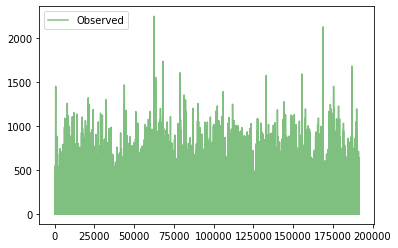

In [291]:
#chr1 9963058 11295918

observed = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/data/naked_unstranded.bw")

#chrom
chrom="chr1"
start=9963058 + 354210              
end=9963058 + 545713  
print(start, end)
#chr2 86746649 86947016
#chr19 54069362 54265160
#chr20 58263927 58450038
#chr3	127212000	127214114

obs = np.nan_to_num(observed.values(chrom, start, end))
signal1 = np.nan_to_num(printbw.values(chrom, start, end))
signal2 = np.nan_to_num(bw.values(chrom, start, end))

#plt.plot(signal1/sum(signal1), label="PRINT", c='b', alpha=0.5)
#plt.plot(signal2/sum(signal2), label="ChromBPNet", c='r', alpha=0.5)
plt.plot(obs, label="Observed", c='g', alpha=0.5)
plt.legend()

In [288]:
np.arange(obs.shape[0])[obs>5]

array([354210, 354213, 354215, ..., 545713, 842081, 842183])

In [293]:
df=pd.read_csv("/mnt/lab_data2/anusri/print_analysis/newselectedBAChg38.txt", sep="\t", header=None)

In [294]:
df.head()

,0,1,2
0,chr1,10317268,10508771
1,chr1,2115312,2276873
2,chr1,69256017,69397675
3,chr1,173236370,173383209
4,chr1,80688374,80857832


chr1 10317268 10508771
2249.0
0.24837208816572065
chr1 2115312 2276873
2190.0
0.15855930577305166
chr1 69256017 69397675
2543.0
0.2340637309576586
chr1 173236370 173383209
2105.0
0.18663978915683163
chr1 80688374 80857832
2184.0
0.2762100343447934
chr2 154054743 154231672
1653.0
0.30096253299346065
chr2 238036072 238243952
1172.0
0.3105589763324995
chr2 37734507 37911723
2405.0
0.2100036114120621
chr1 245911087 246069785
2430.0
0.1972992728326759
chr11 33758373 33929365
1841.0
0.22612168990362122
chrX 48722467 48905921
925.0
0.3095871444612818
chr4 105023617 105231538
1538.0
0.28784009311228786
chr2 218171158 218331153
1359.0
0.2629019656864277
chr20 58263927 58450038
2092.0
0.2563094067518846
chr7 5513181 5666430
1169.0
0.2502463311342978
chr19 54069362 54265160
822.0
0.32893594418737676
chr2 86746649 86947016
321.0
0.6801668937499689
chr7 27106962 27263555
1381.0
0.21826646146379466
chr2 28310682 28530879
122.0
0.6540552323601139
chr5 133980755 134159430
1038.0
0.2750860500909473
chr

/users/anusri/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


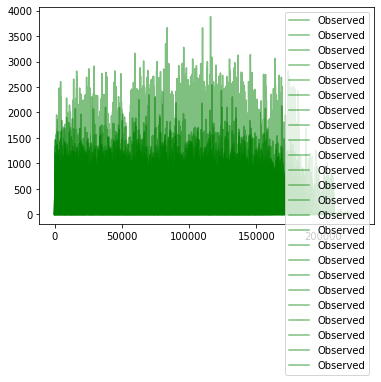

In [296]:
observed = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/data/naked_unstranded.bw")
for i,r in df.iterrows():
    obs = np.nan_to_num(observed.values(r[0], r[1], r[2]))
    #print(obs.shape)
    print(r[0], r[1], r[2])
    print(np.max(obs))
    print(sum(obs<=0)/obs.shape[0])
    plt.plot(obs, label="Observed", c='g', alpha=0.5)
    plt.legend()

In [12]:
import pyBigWig 
chrom="chr1"
tn5_observed = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/data/naked_unstranded.bw")
printbw = pyBigWig.open("printTn5bias.bw")
bw = pyBigWig.open("/mnt/lab_data2/anusri/print_analysis/make_bg_bigwig/GM12878/ATAC_bias_fold0_"+chrom+"_w_bias.bw")
observed = pyBigWig.open("/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/ATAC_PE/GM12878/data/GM12878_unstranded.bw")



In [95]:
import numpy as np
import matplotlib.pyplot as plt
chrom="chr1"
start=9963058 + 354210 + 1000             
#end=9963058 + 545713  
end=start+1000

coordinates = []
chrombpnet_invivo = []
chrombpnet_naked = []
print_invivo = []
print_naked = []
observed_pear = []
for start in range(9963058 + 354210, 9963058 + 545713, 1000):
    #print(start)
    end = start + 2000
    coordinates.append(start)
    obs = np.nan_to_num(observed.values(chrom, start, end))
    tn5_obs = np.nan_to_num(tn5_observed.values(chrom, start, end))
    signal1 = np.nan_to_num(printbw.values(chrom, start, end))
    signal2 = np.nan_to_num(bw.values(chrom, start, end))

    print_invivo.append(pearsonr(obs, signal1/sum(signal1))[0])
    print_naked.append(pearsonr(tn5_obs, signal1/sum(signal1))[0])
    
    chrombpnet_invivo.append(pearsonr(obs, signal2/sum(signal2))[0])
    chrombpnet_naked.append(pearsonr(tn5_obs, signal2/sum(signal2))[0])
    
    observed_pear.append(pearsonr(obs,tn5_obs)[0])


In [96]:
import pandas as pd

df = pd.DataFrame()
df["chrombpnet_invivo"] = chrombpnet_invivo
df["chrombpnet_naked"] = chrombpnet_naked
df["print_invivo"] = print_invivo
df["print_naked"] = print_naked
df["observed_pear"] = observed_pear
df["coordinates"] = coordinates


In [97]:
df[df["chrombpnet_invivo"]>0.68]

,chrombpnet_invivo,chrombpnet_naked,print_invivo,print_naked,observed_pear,coordinates
61,0.6958,0.932191,0.578261,0.91635,0.664488,10378268


Text(0, 0.5, 'PRINT')

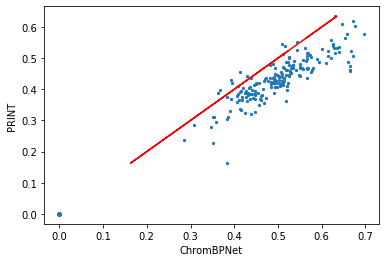

In [56]:
plt.plot(print_invivo, print_invivo, c="r")
plt.scatter(chrombpnet_invivo, print_invivo, s=5)
plt.xlabel("ChromBPNet")
plt.ylabel("PRINT")


Text(0, 0.5, 'PRINT')

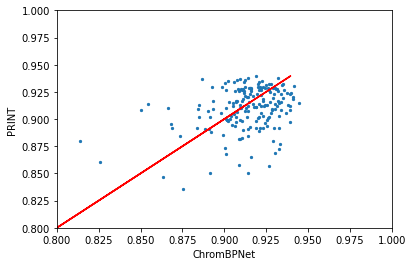

In [58]:
plt.plot(print_naked, print_naked, c="r")
plt.scatter(chrombpnet_naked, print_naked, s=5)
plt.xlim(0.8,1)
plt.ylim(0.8,1)
plt.xlabel("ChromBPNet")
plt.ylabel("PRINT")


In [84]:
observed_pears = np.array([x[0] for x in observed_pear])
newd = observed_pears[observed_pears<0.5]
np.array(coordinates)[observed_pears<0.5]

TypeError: '>' not supported between instances of 'list' and 'float'

(0.6644882821962068, 4.680289376551812e-255)

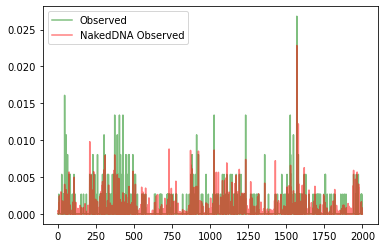

In [100]:
start=10378268
end=start+2000
obs = np.nan_to_num(observed.values(chrom, start, end))
tn5_obs = np.nan_to_num(tn5_observed.values(chrom, start, end))
signal1 = np.nan_to_num(printbw.values(chrom, start, end))
signal2 = np.nan_to_num(bw.values(chrom, start, end))
    
plt.plot(obs/sum(obs), label="Observed", c='g', alpha=0.5)
plt.plot(tn5_obs/sum(tn5_obs), label="NakedDNA Observed", c='r', alpha=0.5)
#plt.plot(signal2/sum(signal2), label="ChromBPNet", c='b', alpha=0.5)
#plt.plot(signal1/sum(signal1), label="PRINT", c='k', alpha=0.5)

plt.legend()

#plt.plot(tn5_obs/sum(tn5_obs), label="NakedDNA Observed", c='r', alpha=0.1)
from scipy.stats import pearsonr
pearsonr(obs, tn5_obs)

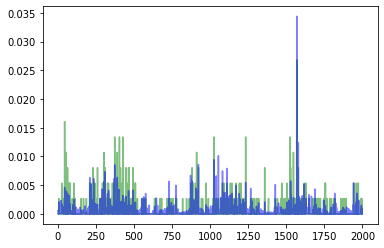

In [101]:
plt.plot(obs/sum(obs), label="Observed", c='g', alpha=0.5)
#plt.plot(tn5_obs/sum(tn5_obs), label="NakedDNA Observed", c='r', alpha=0.5)
plt.plot(signal2/sum(signal2), label="ChromBPNet", c='b', alpha=0.5)
#plt.plot(signal1/sum(signal1), label="PRINT", c='k', alpha=0.5)


In [80]:
pearsonr(obs, signal1)

(0.4372656254700932, 3.4879642049029095e-94)

In [81]:
pearsonr(obs, signal2)

(0.4890501404891713, 9.28677491769586e-121)

In [82]:
pearsonr(tn5_obs, signal1/sum(signal1))

(0.9021698612959669, 0.0)

In [83]:
pearsonr(tn5_obs, signal2/sum(signal2))

(0.9205661631605744, 0.0)